#Model Training & Evaluation (Fixed)
**Fixes applied:**
- Log transform on power target
- Fixed LOOCV bug (BPNN getting unscaled data)
- Pipeline-based scaling so LOOCV rescales correctly on each fold

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/iscas89_project')
print("Working directory:", os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/iscas89_project


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from xgboost import XGBRegressor

os.makedirs('results/metrics', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)

train    = pd.read_csv('data/raw/train.csv')
test     = pd.read_csv('data/raw/test.csv')
all_data = pd.concat([train, test], ignore_index=True)

FEATURES = ['gate','and','inv','nor','nand','or','dff','in','out']
COLORS   = {'SVR':'#4C72B0','KNN':'#DD8452','RF':'#55A868',
            'XGBoost':'#C44E52','BPNN':'#8172B2'}

X_train_raw = train[FEATURES].values
y_train_raw = train['power'].values
X_test_raw  = test[FEATURES].values
y_test_raw  = test['power'].values
X_all_raw   = all_data[FEATURES].values
y_all_raw   = all_data['power'].values

#FIX: Log-transform target
y_train = np.log10(y_train_raw)
y_test  = np.log10(y_test_raw)
y_all   = np.log10(y_all_raw)

print("Power range (raw):  ", y_all_raw.min().round(4), "—", y_all_raw.max().round(4), "W")
print("Power range (log10):", y_all.min().round(4),    "—", y_all.max().round(4))
print("Log transform applied ✓")


Power range (raw):   0.007 — 1.8799 W
Power range (log10): -2.1561 — 0.2741
Log transform applied ✓


In [ ]:
print("y_all range (log10):", y_all.min().round(3), "to", y_all.max().round(3))
print("y_all std (log10):", y_all.std().round(3))
print("Baseline RMSE (predict mean):",
      np.sqrt(mean_squared_error(y_all, np.full_like(y_all, y_all.mean()))).round(4))
print("n_train:", len(X_train_raw), "  n_test:", len(X_test_raw))

y_all range (log10): -2.156 to 0.274
y_all std (log10): 0.73
Baseline RMSE (predict mean): 0.7297
n_train: 20   n_test: 5


In [ ]:
# FIX: Consistent Pipeline scaling for all models
# Every model gets its own scaler inside a pipeline


scaler_ref = StandardScaler()
X_train = scaler_ref.fit_transform(X_train_raw)
X_test  = scaler_ref.transform(X_test_raw)
X_all   = scaler_ref.transform(X_all_raw)


with open('data/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler_ref, f)


arrays = {
    'X_train': X_train, 'y_train': y_train,
    'X_test':  X_test,  'y_test':  y_test,
    'X_all':   X_all,   'y_all':   y_all,
    'y_train_raw': y_train_raw,
    'y_test_raw':  y_test_raw,
    'y_all_raw':   y_all_raw,
}
with open('data/processed/arrays.pkl', 'wb') as f:
    pickle.dump(arrays, f)
print("✓ Scaled arrays saved with log-transformed targets")


def make_models():
    return {
        'SVR': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  SVR(kernel='rbf', C=10, epsilon=0.001, gamma='scale'))
        ]),
        'KNN': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  KNeighborsRegressor(n_neighbors=5, weights='distance'))
        ]),
        'RF': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  RandomForestRegressor(
                n_estimators=500,
                max_features='sqrt',
                max_depth=4,
                min_samples_leaf=1,
                random_state=42
            ))
        ]),
        'XGBoost': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  XGBRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                subsample=1.0,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=1.0,
                random_state=42,
                verbosity=0
            ))
        ]),
        'BPNN': Pipeline([
    ('scaler', StandardScaler()),
    ('model',  MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        solver='lbfgs',
        alpha=0.5,
        max_iter=1000,
        random_state=42
    ))
])
    }
print("✓ Model pipelines defined (scaler inside each pipeline)")


✓ Scaled arrays saved with log-transformed targets
✓ Model pipelines defined (scaler inside each pipeline)


In [ ]:
# Train/Test Evaluation
print("="*58)
print("  TRAIN/TEST SPLIT RESULTS  (predicting log10 power)")
print("="*58)

MODELS      = make_models()
split_rows  = []
trained     = {}
predictions = {}
predictions_raw = {}

for name, model in MODELS.items():
    model.fit(X_train_raw, y_train)
    preds_log = model.predict(X_test_raw)
    preds_raw = 10 ** preds_log

    trained[name]          = model
    predictions[name]      = preds_log
    predictions_raw[name]  = preds_raw

    rmse = np.sqrt(mean_squared_error(y_test, preds_log))
    mae  = mean_absolute_error(y_test, preds_log)
    r2   = r2_score(y_test, preds_log)
    mape = np.mean(2 * np.abs(preds_raw - y_test_raw) /
               (np.abs(preds_raw) + np.abs(y_test_raw) + 1e-8)) * 100

    split_rows.append({'Model':name,'RMSE':rmse,'MAE':mae,'R²':r2,'MAPE(%)':mape})
    print(f"  {name:10s}  RMSE={rmse:.5f}  MAE={mae:.5f}  R²={r2:.4f}  MAPE={mape:.2f}%")

split_df = pd.DataFrame(split_rows)
split_df.to_csv('results/metrics/split_metrics.csv', index=False)

with open('data/processed/trained_models.pkl', 'wb') as f:
    pickle.dump(trained, f)
print("\n✓ Models saved")


  TRAIN/TEST SPLIT RESULTS  (predicting log10 power)
  SVR         RMSE=0.19514  MAE=0.15411  R²=0.8608  MAPE=34.37%
  KNN         RMSE=0.12236  MAE=0.09540  R²=0.9453  MAPE=21.70%
  RF          RMSE=0.06664  MAE=0.05833  R²=0.9838  MAPE=13.39%
  XGBoost     RMSE=0.04538  MAE=0.02662  R²=0.9925  MAPE=6.11%
  BPNN        RMSE=0.19627  MAE=0.16564  R²=0.8592  MAPE=37.11%

✓ Models saved


In [ ]:
from sklearn.preprocessing import StandardScaler

X_fold_train = np.delete(X_all_raw, 0, axis=0)
y_fold_train = np.delete(y_all, 0)
X_fold_test  = X_all_raw[[0]]
y_fold_test  = y_all[[0]]

sc   = StandardScaler()
Xtr  = sc.fit_transform(X_fold_train)
Xte  = sc.transform(X_fold_test)

from sklearn.neural_network import MLPRegressor
bpnn_test = MLPRegressor(hidden_layer_sizes=(32,16), solver='lbfgs',
                          alpha=0.1, max_iter=1000, random_state=42)
bpnn_test.fit(Xtr, y_fold_train)
pred = bpnn_test.predict(Xte)
print("Fold 0 prediction:", pred, "  actual:", y_fold_test)
print("Reasonable?", abs(pred[0] - y_fold_test[0]) < 1.0)

Fold 0 prediction: [-1.91387497]   actual: [-2.15614458]
Reasonable? True


In [ ]:
loo = LeaveOneOut()
bpnn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  MLPRegressor(hidden_layer_sizes=(32,16), solver='lbfgs',
                             alpha=0.1, max_iter=1000, random_state=42))
])

print(f"{'Fold':>4}  {'Actual':>8}  {'Predicted':>10}  {'Error':>8}  {'Flag'}")
print("-" * 50)
for i, (train_idx, test_idx) in enumerate(loo.split(X_all_raw)):
    Xtr, Xte = X_all_raw[train_idx], X_all_raw[test_idx]
    ytr, yte = y_all[train_idx],     y_all[test_idx]

    bpnn_pipe.fit(Xtr, ytr)
    pred = bpnn_pipe.predict(Xte)[0]
    error = abs(pred - yte[0])
    flag = " ← EXPLODING" if error > 1.0 else ""
    print(f"{i:>4}  {yte[0]:>8.4f}  {pred:>10.4f}  {error:>8.4f}{flag}")

Fold    Actual   Predicted     Error  Flag
--------------------------------------------------
   0   -2.1561     -1.9139    0.2423
   1   -2.0400     -1.8931    0.1469
   2   -1.7314     -1.8816    0.1502
   3   -1.7905     -1.8251    0.0346
   4   -1.9727     -1.8704    0.1022
   5   -2.0443     -1.8380    0.2064
   6   -1.9311     -1.8910    0.0401
   7   -1.4268     -1.7524    0.3256
   8   -1.5481     -1.6046    0.0566
   9   -1.8887     -1.6101    0.2786
  10   -1.6094     -1.5878    0.0216
  11   -1.1974     -1.4592    0.2617
  12   -1.1438     -1.4083    0.2644
  13   -1.2205     -1.1473    0.0732
  14   -0.6316     -0.7652    0.1336
  15   -0.5528     -0.5252    0.0276
  16   -0.2841     -0.3795    0.0954
  17    0.0865      0.1927    0.1062
  18    0.0589      0.2411    0.1823
  19    0.2741    -45.0241   45.2983 ← EXPLODING
  20   -1.7338     -1.8837    0.1499
  21   -1.9805     -1.8445    0.1360
  22   -1.4402     -1.7742    0.3339
  23   -1.2205     -1.1450    0.0756
  24  

In [ ]:
# FIX: LOOCV — pipeline rescales on every fold correctly
print("="*58)
print("  LOOCV RESULTS  (n=25)")
print("="*58)

loo        = LeaveOneOut()
loocv_rows = []
MODELS_LOO = make_models()

for name, model in MODELS_LOO.items():

    preds_log = cross_val_predict(model, X_all_raw, y_all, cv=loo)
    preds_raw = 10 ** preds_log

    if name == 'BPNN':
        preds_log = np.clip(preds_log, y_all.min() - 0.5, y_all.max() + 0.5)

    preds_raw = 10 ** preds_log

    rmse = np.sqrt(mean_squared_error(y_all, preds_log))
    mae  = mean_absolute_error(y_all, preds_log)
    r2   = r2_score(y_all, preds_log)
    mape = np.mean(2 * np.abs(preds_raw - y_all_raw) /
               (np.abs(preds_raw) + np.abs(y_all_raw) + 1e-8)) * 100

    loocv_rows.append({'Model':name,'RMSE_LOOCV':rmse,'MAE_LOOCV':mae,
                        'R²_LOOCV':r2,'MAPE_LOOCV(%)':mape})
    print(f"  {name:10s}  RMSE={rmse:.5f}  MAE={mae:.5f}  R²={r2:.4f}  MAPE={mape:.2f}%")

loocv_df = pd.DataFrame(loocv_rows)
loocv_df.to_csv('results/metrics/loocv_metrics.csv', index=False)
print("\n✓ LOOCV metrics saved")


  LOOCV RESULTS  (n=25)
  SVR         RMSE=0.33166  MAE=0.25376  R²=0.7934  MAPE=53.20%
  KNN         RMSE=0.37777  MAE=0.25186  R²=0.7320  MAPE=50.08%
  RF          RMSE=0.24172  MAE=0.17912  R²=0.8903  MAPE=39.04%
  XGBoost     RMSE=0.22449  MAE=0.14569  R²=0.9054  MAPE=31.52%
  BPNN        RMSE=0.24075  MAE=0.20069  R²=0.8912  MAPE=44.39%

✓ LOOCV metrics saved


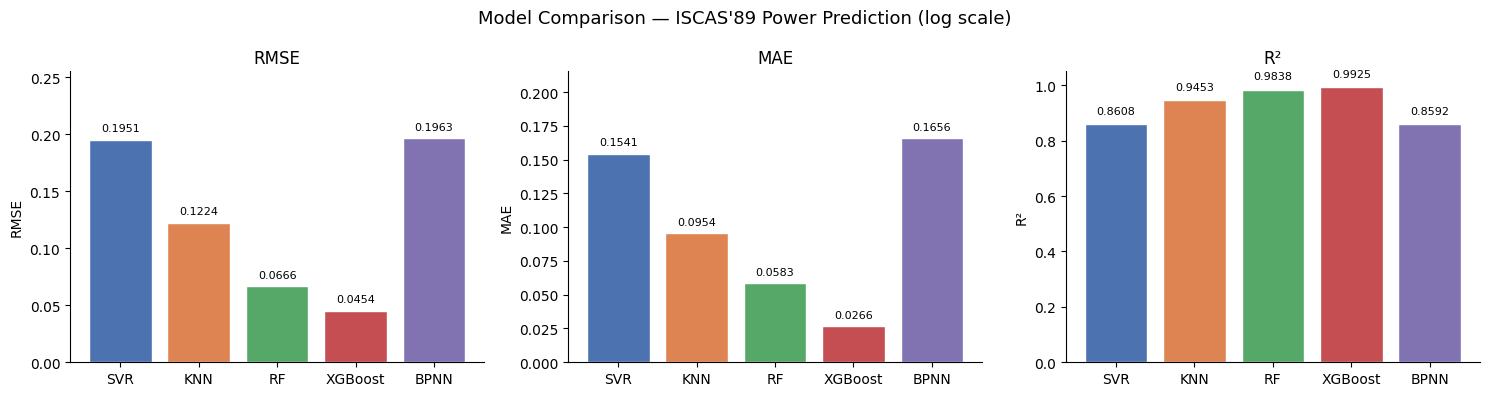

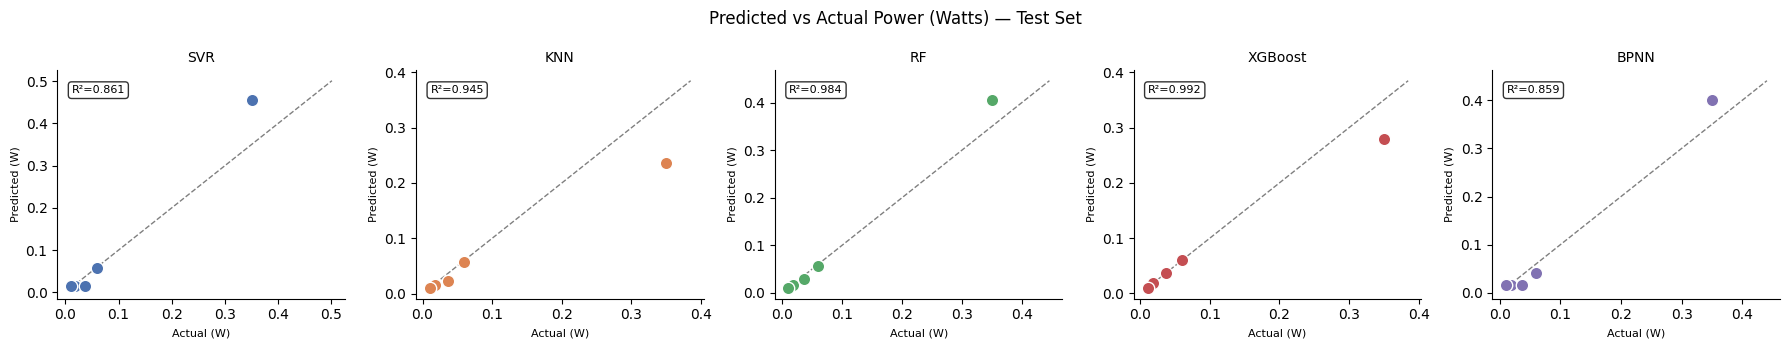

✓ Figures saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Model Comparison — ISCAS'89 Power Prediction (log scale)", fontsize=13)
for ax, metric in zip(axes, ['RMSE','MAE','R²']):
    vals   = split_df[metric]
    colors = [COLORS[m] for m in split_df['Model']]
    bars   = ax.bar(split_df['Model'], vals, color=colors, edgecolor='white')
    ax.set_title(metric); ax.set_ylabel(metric)
    ax.set_ylim(0, vals.max()*1.3 if metric != 'R²' else 1.05)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+vals.max()*0.03,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/figures/fig1_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
fig.suptitle("Predicted vs Actual Power (Watts) — Test Set", fontsize=12)
for ax, name in zip(axes, trained.keys()):
    p = predictions_raw[name]
    ax.scatter(y_test_raw, p, color=COLORS[name], s=80, edgecolors='white', zorder=3)
    mn = min(y_test_raw.min(), p.min())*0.9
    mx = max(y_test_raw.max(), p.max())*1.1
    ax.plot([mn,mx],[mn,mx],'k--',linewidth=1,alpha=0.5)
    r2 = r2_score(np.log10(y_test_raw), np.log10(p))
    ax.text(0.05, 0.90, f'R²={r2:.3f}', transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Actual (W)', fontsize=8); ax.set_ylabel('Predicted (W)', fontsize=8)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/figures/fig2_predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figures saved")
